In [3]:
from google.colab import files
uploaded = files.upload()

Saving olist_products_dataset.csv to olist_products_dataset (1).csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset (1).csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)


Orders: (99441, 8)
Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)


In [6]:
# Merge orders + items
df = orders.merge(items, on='order_id', how='inner')

# Merge with products
df = df.merge(products, on='product_id', how='left')

# Merge with payments
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()
df = df.merge(payments_agg, on='order_id', how='left')

print("Master table shape:", df.shape)
df.head()

Master table shape: (112650, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,28.62


In [7]:
# Check nulls
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with missing product category
df.dropna(subset=['product_category_name'], inplace=True)

# Convert date columns
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Extract useful time features
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.day_name()

# Keep only delivered orders for revenue analysis
df = df[df['order_status'] == 'delivered']

print("Cleaned shape:", df.shape)
print(f"Date range: {df['order_purchase_timestamp'].min()} to {df['order_purchase_timestamp'].max()}")

order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
product_category_name            1603
product_name_lenght              1603
product_description_lenght       1603
product_photos_qty               1603
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
payment_value                       3
dtype: int64
Cleaned shape: (108660, 26)
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


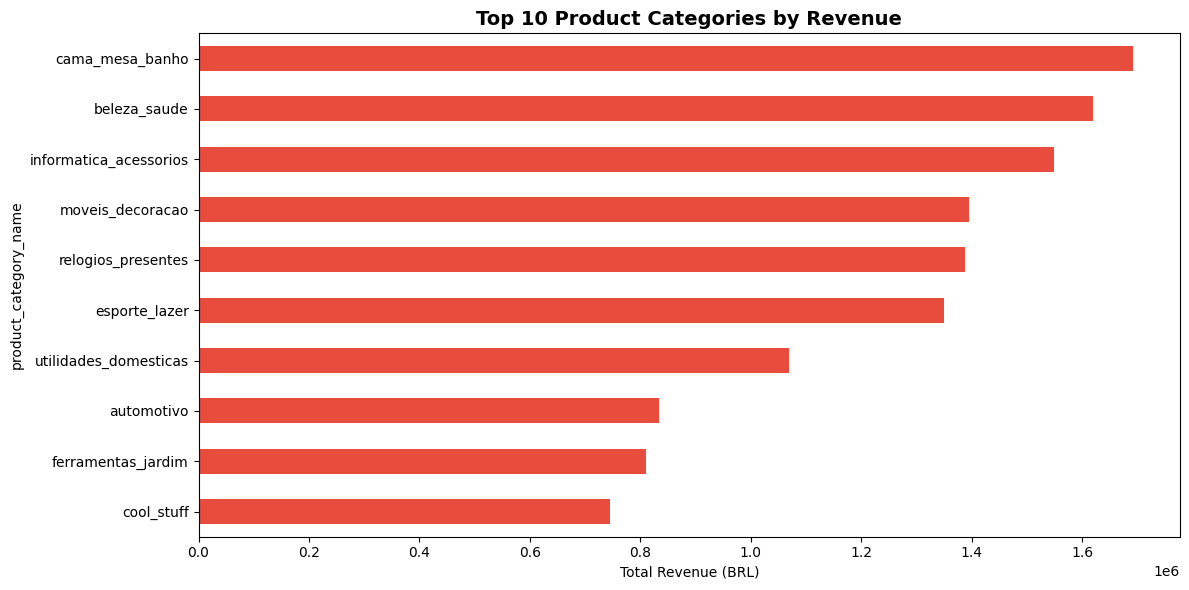

product_category_name
cama_mesa_banho           1692714.28
beleza_saude              1620684.04
informatica_acessorios    1549372.59
moveis_decoracao          1394466.93
relogios_presentes        1387362.45
esporte_lazer             1349446.93
utilidades_domesticas     1069787.97
automotivo                 833745.67
ferramentas_jardim         810614.93
cool_stuff                 744649.32
Name: payment_value, dtype: float64


In [8]:
category_revenue = df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
category_revenue.plot(kind='barh', color='#E74C3C')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_categories_revenue.png', dpi=150)
plt.show()
print(category_revenue)

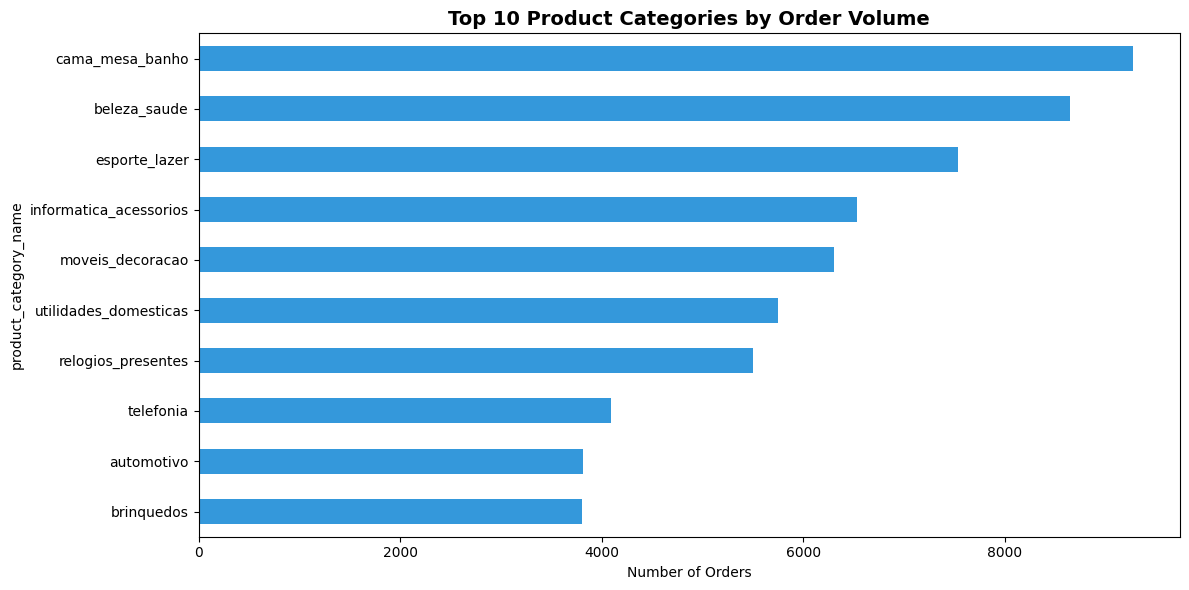

In [9]:
category_orders = df.groupby('product_category_name')['order_id'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
category_orders.plot(kind='barh', color='#3498DB')
plt.title('Top 10 Product Categories by Order Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_categories_orders.png', dpi=150)
plt.show()

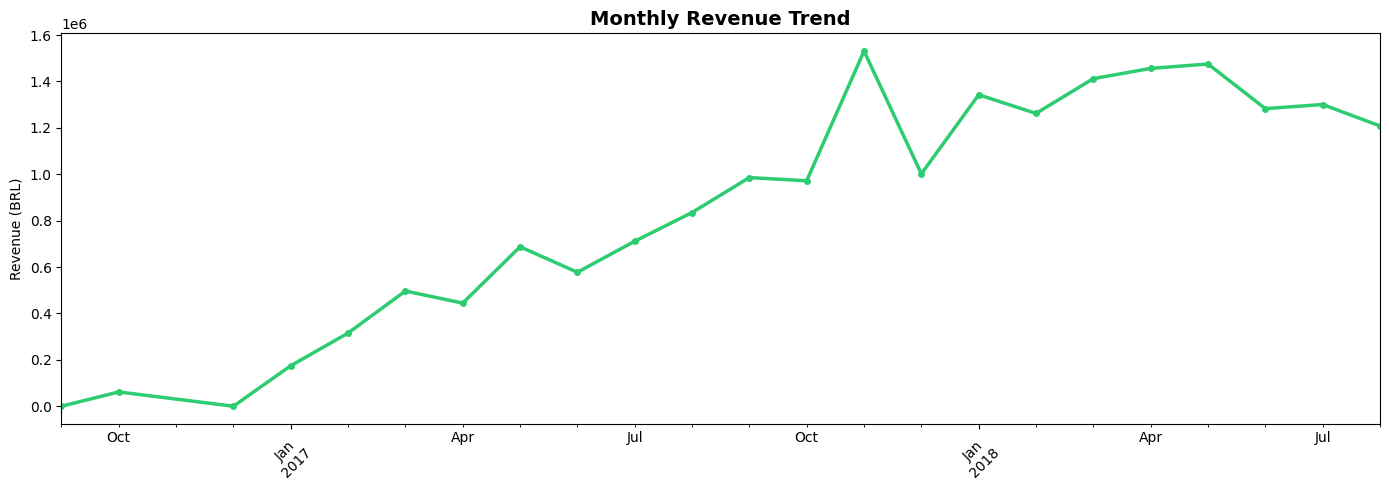

In [10]:
monthly_revenue = df.groupby('order_month')['payment_value'].sum()

plt.figure(figsize=(14,5))
monthly_revenue.plot(kind='line', color='#2ECC71', linewidth=2.5, marker='o', markersize=4)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (BRL)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()

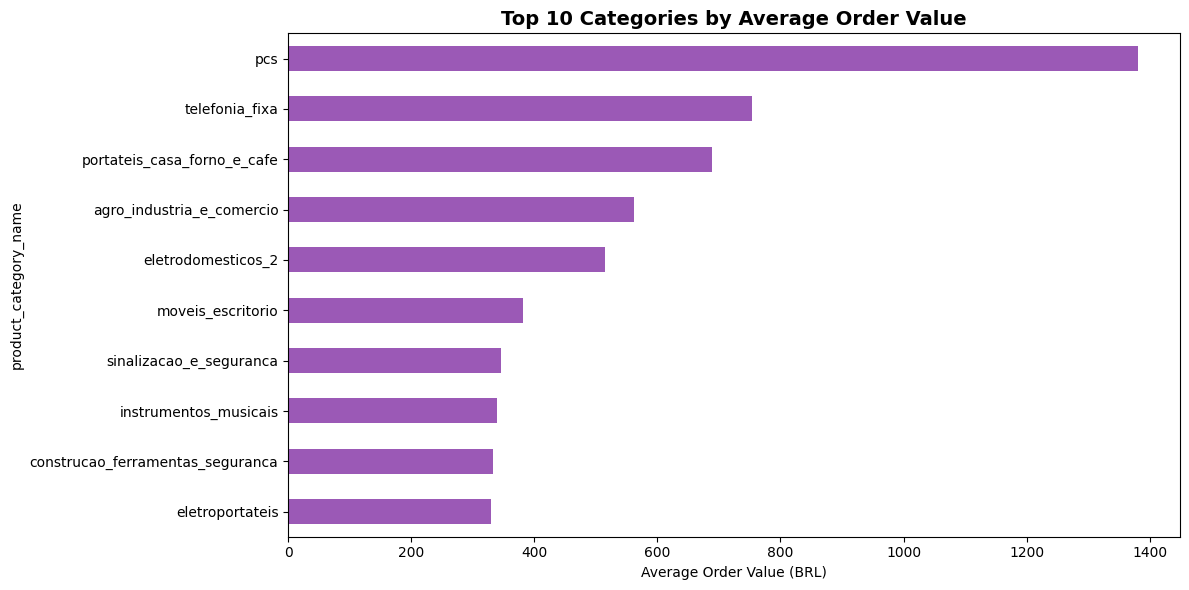

In [11]:
avg_order_value = df.groupby('product_category_name')['payment_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
avg_order_value.plot(kind='barh', color='#9B59B6')
plt.title('Top 10 Categories by Average Order Value', fontsize=14, fontweight='bold')
plt.xlabel('Average Order Value (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('avg_order_value.png', dpi=150)
plt.show()

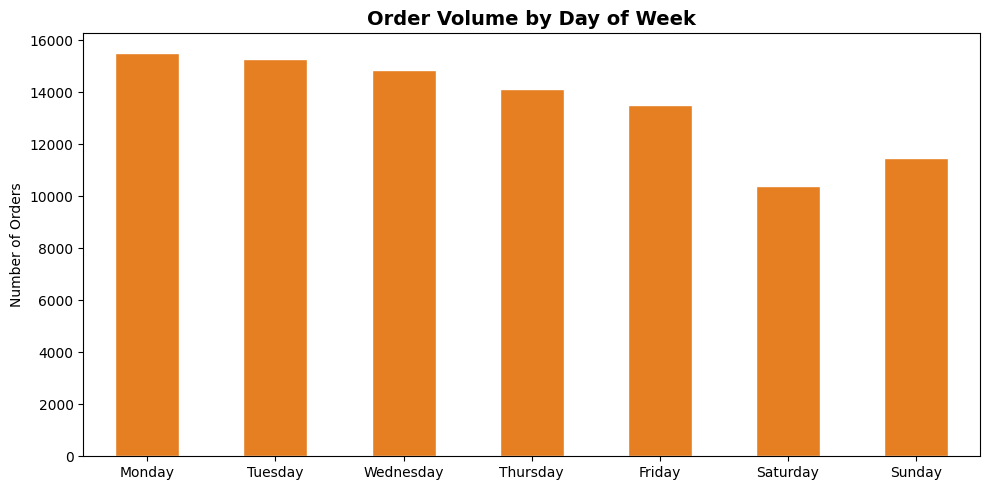

In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
orders_by_day = df.groupby('order_dayofweek')['order_id'].nunique().reindex(day_order)

plt.figure(figsize=(10,5))
orders_by_day.plot(kind='bar', color='#E67E22', edgecolor='white')
plt.title('Order Volume by Day of Week', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('orders_by_day.png', dpi=150)
plt.show()

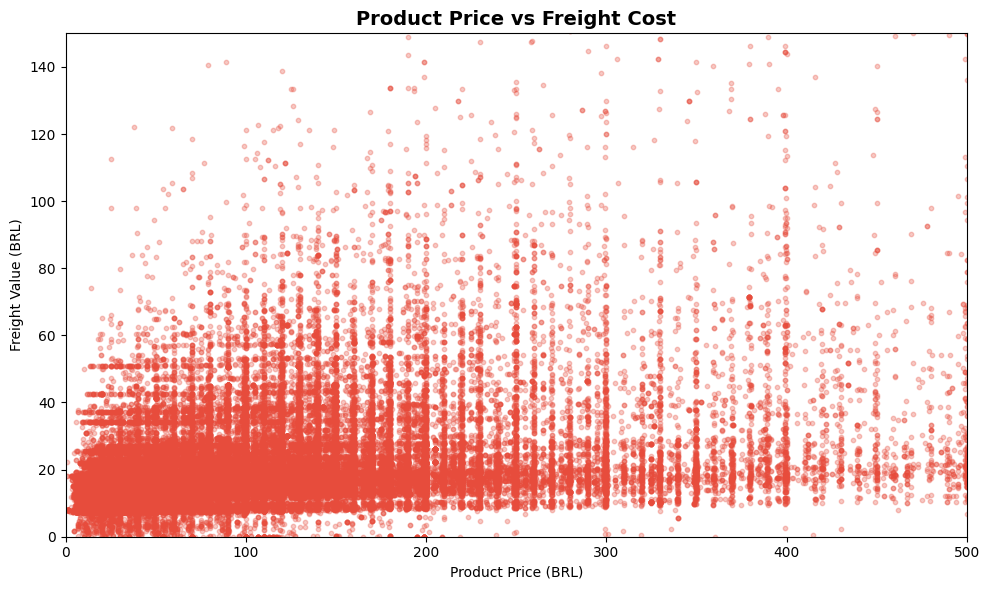

Average freight as % of price: 23.2%


In [13]:
plt.figure(figsize=(10,6))
plt.scatter(df['price'], df['freight_value'],
            alpha=0.3, color='#E74C3C', s=10)
plt.title('Product Price vs Freight Cost', fontsize=14, fontweight='bold')
plt.xlabel('Product Price (BRL)')
plt.ylabel('Freight Value (BRL)')
plt.xlim(0, 500)
plt.ylim(0, 150)
plt.tight_layout()
plt.savefig('price_vs_freight.png', dpi=150)
plt.show()

# Freight as % of price
df['freight_pct'] = (df['freight_value'] / df['price']) * 100
print(f"Average freight as % of price: {df['freight_pct'].median():.1f}%")

In [15]:
total_revenue = df['payment_value'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = df['payment_value'].mean()
total_products = df['product_id'].nunique()

print("=" * 40)
print(f"Total Revenue:       BRL {total_revenue:,.0f}")
print(f"Total Orders:        {total_orders:,}")
print(f"Avg Order Value:     BRL {avg_order_value:.2f}")
print(f"Unique Products:     {total_products:,}")
print("=" * 40)

Total Revenue:       BRL 19,535,165
Total Orders:        95,146
Avg Order Value:     BRL 179.79
Unique Products:     31,632


In [16]:
category_summary = df.groupby('product_category_name').agg(
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('payment_value', 'mean'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

category_summary.to_csv('category_summary.csv', index=False)

monthly_summary = df.groupby('order_month').agg(
    revenue=('payment_value', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()
monthly_summary['order_month'] = monthly_summary['order_month'].astype(str)
monthly_summary.to_csv('monthly_summary.csv', index=False)

from google.colab import files
files.download('category_summary.csv')
files.download('monthly_summary.csv')
files.download('top_categories_revenue.png')
files.download('top_categories_orders.png')
files.download('monthly_revenue_trend.png')
files.download('avg_order_value.png')
files.download('orders_by_day.png')
files.download('price_vs_freight.png')

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
